In [15]:
import os
import glob
import shutil
import pandas as pd
from PIL import Image

# Output directory expected by XYDataset
OUTPUT_DIR = 'dataset_xy'
os.makedirs(OUTPUT_DIR, exist_ok=True)

dataset_root = 'dataset'
session_csvs = glob.glob(os.path.join(dataset_root, '*.csv'))

copied, skipped = 0, 0

for csv_path in session_csvs:
    session_name = os.path.splitext(os.path.basename(csv_path))[0]
    image_dir = os.path.join(dataset_root, session_name)

    if not os.path.isdir(image_dir):
        print(f"Skipping {session_name} — no matching image folder found")
        continue

    df = pd.read_csv(csv_path, header=None, names=['frame', 'x', 'y'])

    for _, row in df.iterrows():
        frame_id = int(row['frame'])
        x, y = row['x'], row['y']

        src = os.path.join(image_dir, f'{frame_id:04d}.jpg')
        if not os.path.exists(src):
            skipped += 1
            continue

        # Filename encodes x and y as integers scaled to [0, 1000]
        # get_x/get_y in XYDataset decode them back assuming width=height=1000
        # x is in [0,1], y is in [-1,1] → convert to pixel coords in a 224x224 image
        x_int = int(x * 224)                    # [0,1]   → [0, 224]
        y_int = int((y + 1.0) / 2.0 * 224)     # [-1,1]  → [0, 224]

        dst_name = f'xy_{x_int:03d}_{y_int:03d}_{session_name}_{frame_id:04d}.jpg'

        dst_name = f'xy_{x_int}_{y_int}_{session_name}_{frame_id:04d}.jpg'
        dst = os.path.join(OUTPUT_DIR, dst_name)
        shutil.copy(src, dst)
        copied += 1

print(f"Done: {copied} images copied, {skipped} skipped (missing files)")

Done: 7584 images copied, 0 skipped (missing files)


# Road Follower - Train Model

In this notebook we will train a neural network to take an input image, and output a set of x, y values corresponding to a target.

We will be using PyTorch deep learning framework to train ResNet18 neural network architecture model for road follower application.

In [16]:
import torch
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.datasets as datasets
import torchvision.models as models
import torchvision.transforms as transforms
import glob
import PIL.Image
import os
import numpy as np

### Download and extract data

Before you start, you should upload the ``road_following_<Date&Time>.zip`` file that you created in the ``data_collection.ipynb`` notebook on the robot. 

> If you're training on the JetBot you collected data on, you can skip this!

You should then extract this dataset by calling the command below:

In [4]:
!unzip -q road_following.zip

unzip:  cannot find or open road_following.zip, road_following.zip.zip or road_following.zip.ZIP.


You should see a folder named ``dataset_all`` appear in the file browser.

### Create Dataset Instance

Here we create a custom ``torch.utils.data.Dataset`` implementation, which implements the ``__len__`` and ``__getitem__`` functions.  This class
is responsible for loading images and parsing the x, y values from the image filenames.  Because we implement the ``torch.utils.data.Dataset`` class,
we can use all of the torch data utilities :)

We hard coded some transformations (like color jitter) into our dataset.  We made random horizontal flips optional (in case you want to follow a non-symmetric path, like a road
where we need to 'stay right').  If it doesn't matter whether your robot follows some convention, you could enable flips to augment the dataset.

In [17]:
def get_x(path, width):
    """Gets the x value from the image filename"""
    return (float(int(path.split("_")[1])) - width/2) / (width/2)

def get_y(path, height):
    """Gets the y value from the image filename"""
    return (float(int(path.split("_")[2])) - height/2) / (height/2)

# def get_x(path, width):
#     return float(int(path.split("_")[1])) / 1000.0

# def get_y(path, height):
#     return (float(int(path.split("_")[2])) / 1000.0) * 2.0 - 1.0

class XYDataset(torch.utils.data.Dataset):
    
    def __init__(self, directory, random_hflips=False):
        self.directory = directory
        self.random_hflips = random_hflips
        self.image_paths = glob.glob(os.path.join(self.directory, '*.jpg'))
        self.color_jitter = transforms.ColorJitter(0.3, 0.3, 0.3, 0.3)
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        
        image = PIL.Image.open(image_path)
        width, height = image.size
        x = float(get_x(os.path.basename(image_path), width))
        y = float(get_y(os.path.basename(image_path), height))
      
        if float(np.random.rand(1)) > 0.5:
            image = transforms.functional.hflip(image)
            x = -x
        
        image = self.color_jitter(image)
        image = transforms.functional.resize(image, (224, 224))
        image = transforms.functional.to_tensor(image)
        image = image.numpy()[::-1].copy()
        image = torch.from_numpy(image)
        image = transforms.functional.normalize(image, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        
        return image, torch.tensor([x, y]).float()

dataset = XYDataset('dataset_xy', random_hflips=False)

### Split dataset into train and test sets
Once we read dataset, we will split data set in train and test sets. In this example we split train and test a 90%-10%. The test set will be used to verify the accuracy of the model we train.

In [18]:
test_percent = 0.1
num_test = int(test_percent * len(dataset))
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [len(dataset) - num_test, num_test])

In [19]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

In [20]:
model = models.resnet18(pretrained=True)

In [21]:
model.fc = torch.nn.Linear(512, 2)
device = torch.device('cuda')
model = model.to(device)
print(device)

cuda


In [ ]:
NUM_EPOCHS = 70
BEST_MODEL_PATH = 'best_steering_model_xy.pth'
best_loss = 1e9

optimizer = optim.Adam(model.parameters())

for epoch in range(NUM_EPOCHS):
    
    model.train()
    train_loss = 0.0
    for images, labels in iter(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = F.mse_loss(outputs, labels)
        train_loss += float(loss)
        loss.backward()
        optimizer.step()
    train_loss /= len(train_loader)
    
    model.eval()
    test_loss = 0.0
    for images, labels in iter(test_loader):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = F.mse_loss(outputs, labels)
        test_loss += float(loss)
    test_loss /= len(test_loader)
    
    print('%f, %f' % (train_loss, test_loss))
    if test_loss < best_loss:
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        best_loss = test_loss

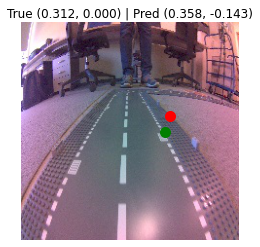

True x: 0.312, True y: 0.000
Pred x: 0.358, Pred y: -0.143


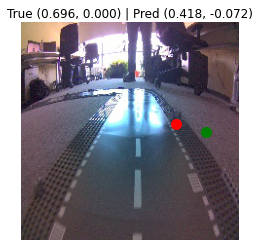

True x: 0.696, True y: 0.000
Pred x: 0.418, Pred y: -0.072


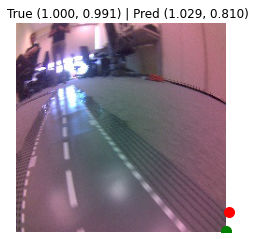

True x: 1.000, True y: 0.991
Pred x: 1.029, Pred y: 0.810


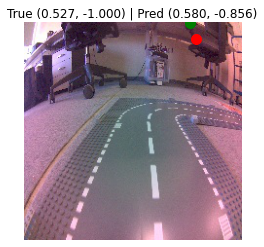

True x: 0.527, True y: -1.000
Pred x: 0.580, Pred y: -0.856


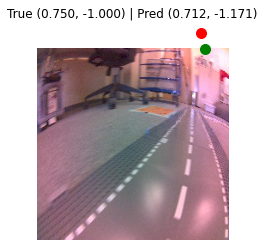

True x: 0.750, True y: -1.000
Pred x: 0.712, Pred y: -1.171


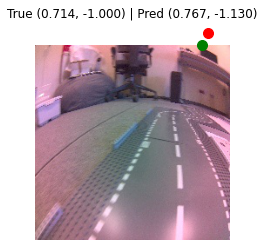

True x: 0.714, True y: -1.000
Pred x: 0.767, Pred y: -1.130


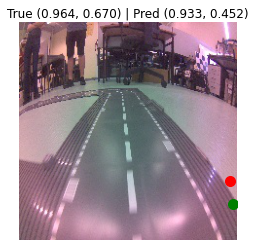

True x: 0.964, True y: 0.670
Pred x: 0.933, Pred y: 0.452


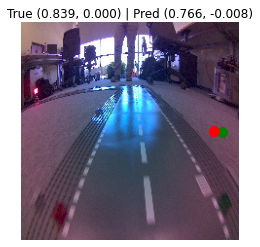

True x: 0.839, True y: 0.000
Pred x: 0.766, Pred y: -0.008


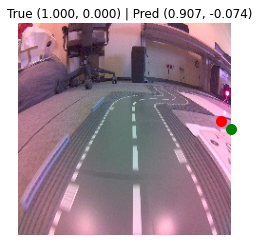

True x: 1.000, True y: 0.000
Pred x: 0.907, Pred y: -0.074


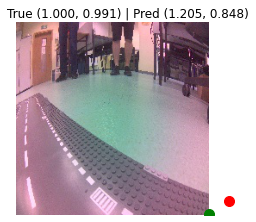

True x: 1.000, True y: 0.991
Pred x: 1.205, Pred y: 0.848


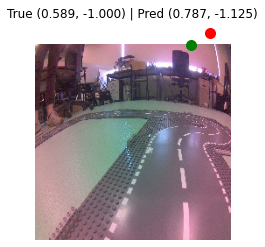

True x: 0.589, True y: -1.000
Pred x: 0.787, Pred y: -1.125


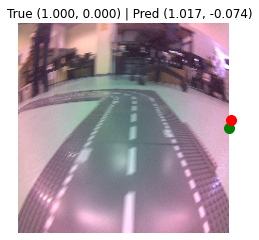

True x: 1.000, True y: 0.000
Pred x: 1.017, Pred y: -0.074


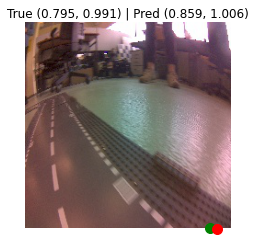

True x: 0.795, True y: 0.991
Pred x: 0.859, Pred y: 1.006


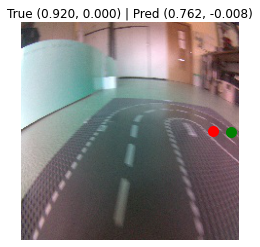

True x: 0.920, True y: 0.000
Pred x: 0.762, Pred y: -0.008


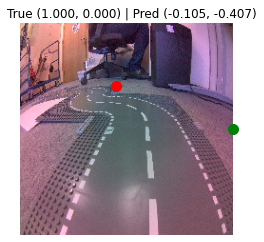

True x: 1.000, True y: 0.000
Pred x: -0.105, Pred y: -0.407


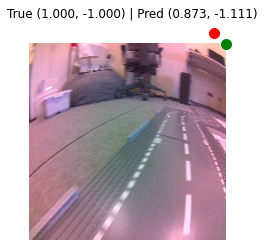

True x: 1.000, True y: -1.000
Pred x: 0.873, Pred y: -1.111


In [34]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
import PIL.Image
import os
import torchvision.transforms as transforms

def get_image_tensor(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),   # ResNet expects 224x224
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet mean
                             [0.229, 0.224, 0.225])    # ImageNet std
    ])
    image = PIL.Image.open(image_path).convert('RGB')
    return transform(image)

model = models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(512, 2)
state_dict = torch.load('best_steering_model_xy.pth', map_location='cpu')
model.load_state_dict(state_dict)
model.eval()

samples = random.sample(dataset.image_paths, 16)

for s in samples:
    image = PIL.Image.open(s)
    width, height = image.size
    
    true_x = get_x(os.path.basename(s), width)
    true_y = get_y(os.path.basename(s), height)
    
    with torch.no_grad():
        output = model(get_image_tensor(s).unsqueeze(0))[0].numpy()
    
    pred_x, pred_y = output[0], output[1]
    
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"True ({true_x:.3f}, {true_y:.3f}) | Pred ({pred_x:.3f}, {pred_y:.3f})")
    plt.scatter((true_x + 1) / 2 * width, (true_y + 1) / 2 * height, color='green', label='True', s=100)
    plt.scatter((pred_x + 1) / 2 * width, (pred_y + 1) / 2 * height, color='red', label='Pred', s=100)
    plt.axis('off')
    plt.show()
    
    print(f"True x: {true_x:.3f}, True y: {true_y:.3f}")
    print(f"Pred x: {pred_x:.3f}, Pred y: {pred_y:.3f}")

Once the model is trained, it will generate ``best_steering_model_xy.pth`` file which you can use for inferencing in the live demo notebook.

If you trained on a different machine other than JetBot, you'll need to upload this to the JetBot to the ``road_following`` example folder.

In [12]:
import torch
state_dict = torch.load('best_steering_model_xy.pth', map_location='cpu')
torch.save(state_dict, 'best_steering_model_xy_cpu.pth', _use_new_zipfile_serialization=False)